# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Imhs14/flyrank-ml-internship-starter-main/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
import os
while not os.path.isdir("data/raw") and os.getcwd() != "/":
    os.chdir("..")
import pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
for c in ["word_count", "scroll_rate"]:
    df[f"{c}_was_missing"] = df[c].isna().astype(int)
    df[c] = df[c].fillna(df[c].median())
df["is_declining"] = (df["trend_direction"] == "down").astype(int)   # evaluation only, never a feature

feat_cols = ["avg_position","ctr","impressions_90d","word_count","content_age_days","engagement_rate","scroll_rate"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
tr, te = next(gss.split(df, groups=df["client_id"]))
train, test = df.iloc[tr].copy(), df.iloc[te].copy()
assert not set(train.client_id) & set(test.client_id)
scaler = StandardScaler().fit(train[feat_cols])
Xtr, Xte = scaler.transform(train[feat_cols]), scaler.transform(test[feat_cols])
print(len(train), len(test), "base rate (test):", round(test.is_declining.mean(), 3))

22885 7115 base rate (test): 0.517


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

   k        inertia  silhouette
0  3  121252.343404    0.238510
1  4  105432.140551    0.246429
2  5   95295.775033    0.279283
3  6   80416.148788    0.287287
4  7   68360.332232    0.301433
5  8   58720.257306    0.317098


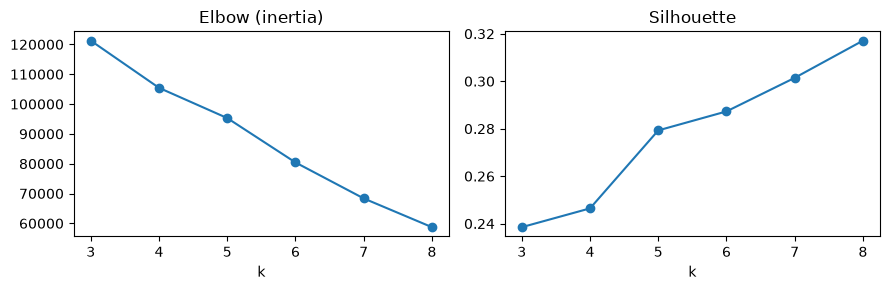

Seed stability ARI: [0.707 0.706 0.951 0.951 0.95 ] mean 0.853


In [2]:
rows = []
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xtr)
    sil = silhouette_score(Xtr, km.labels_, sample_size=5000, random_state=42)
    rows.append((k, km.inertia_, sil))
sweep = pd.DataFrame(rows, columns=["k", "inertia", "silhouette"]); print(sweep)

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(sweep.k, sweep.inertia, "o-"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(sweep.k, sweep.silhouette, "o-"); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.savefig("k_selection.png", dpi=150); plt.show()

# stability: same k, different seeds -> do the groups agree? (ARI near 1 = stable)
K_CLUSTERS = 5
base = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10).fit(Xtr).labels_
aris = [adjusted_rand_score(base, KMeans(n_clusters=K_CLUSTERS, random_state=s, n_init=10).fit(Xtr).labels_) for s in range(1, 6)]
print("Seed stability ARI:", np.round(aris, 3), "mean", round(np.mean(aris), 3))

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

         pages  impressions    ctr  position  engagement   scroll  age_days  \
cluster                                                                       
0         3330       5651.5  0.135     19.40        0.76    4.100     229.0   
1         9268       1250.0  0.140      9.50        0.00    4.665     125.0   
2         8090        575.0  0.040     11.65        0.00    0.000     362.0   
3          354        214.5  0.120     10.55       50.00   50.000     251.5   
4         1843         23.0  0.000      8.00        0.00  100.000     282.0   

         decline_rate  
cluster                
0               0.634  
1               0.635  
2               0.438  
3               0.497  
4               0.472  
         pages  decline_rate   action  \
cluster                                 
0         3330         0.634  rewrite   
1         9268         0.635  rewrite   
2         8090         0.438  protect   
3          354         0.497  monitor   
4         1843         0.472  pr

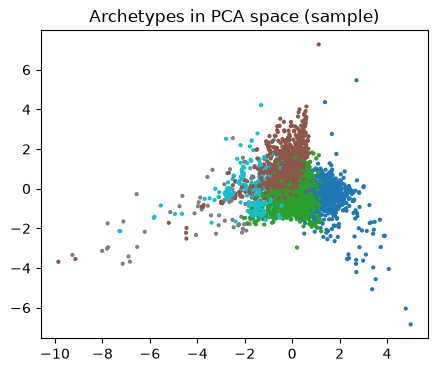

In [3]:
km = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10).fit(Xtr)
train["cluster"], test["cluster"] = km.labels_, km.predict(Xte)

prof = train.groupby("cluster").agg(
    pages=("cluster", "size"), impressions=("impressions_90d", "median"), ctr=("ctr", "median"),
    position=("avg_position", "median"), engagement=("engagement_rate", "median"),
    scroll=("scroll_rate", "median"), age_days=("content_age_days", "median"),
    decline_rate=("is_declining", "mean")).round(3)
print(prof)

# rule-based action + reason code, relative to the train medians (check the names against the table before you publish)
med = train[["impressions_90d", "ctr", "engagement_rate"]].median()
def action(r):
    hi_imp, low_ctr, low_eng = r.impressions >= med.impressions_90d, r.ctr < med.ctr, r.engagement < med.engagement_rate
    if r.decline_rate >= 0.60 and hi_imp and low_ctr: return ("improve", "R1: visible, weak CTR, high observed decline rate")
    if r.decline_rate >= 0.60:                         return ("rewrite", "R2: high observed decline rate, low pull")
    if r.pages < 500:                                  return ("monitor", "R3: small niche group")
    if not hi_imp and low_eng:                         return ("merge_or_prune", "R4: low visibility and low engagement")
    return ("protect", "R5: below-average decline rate")
prof[["action", "reason_code"]] = prof.apply(lambda r: pd.Series(action(r)), axis=1)
prof.to_csv("archetype_action_playbook.csv"); print(prof[["pages", "decline_rate", "action", "reason_code"]])

pcs = PCA(n_components=2, random_state=42).fit_transform(Xtr)
s = np.random.RandomState(42).choice(len(pcs), 4000, replace=False)
plt.figure(figsize=(5, 4)); plt.scatter(pcs[s, 0], pcs[s, 1], c=train["cluster"].values[s], s=4, cmap="tab10")
plt.title("Archetypes in PCA space (sample)"); plt.savefig("pca_clusters.png", dpi=150); plt.show()

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

                 method  precision@200
0    Base rate (random)          0.517
1  Week-4 rule baseline          0.785
2     Cluster archetype          0.590


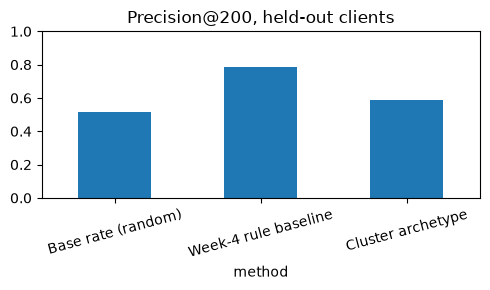

In [4]:
K = 200
risky = prof["decline_rate"].idxmax()                     # chosen from TRAIN only
cent = km.cluster_centers_[risky]
tc = test[test.cluster == risky].copy()
tc["dist"] = np.linalg.norm(Xte[(test.cluster == risky).values] - cent, axis=1)
p_cluster = tc.sort_values("dist").head(K).is_declining.mean()

peer = test.groupby("position_tier")["ctr"].transform("mean")
test["b"] = (test.impressions_90d >= 300).astype(int) * (peer - test["ctr"]).clip(lower=0)
p_base = test.sort_values("b", ascending=False).head(K).is_declining.mean()
p_rand = test.is_declining.mean()

res = pd.DataFrame({"method": ["Base rate (random)", "Week-4 rule baseline", "Cluster archetype"],
                    "precision@200": [p_rand, p_base, p_cluster]}).round(3)
print(res); res.to_csv("results_table.csv", index=False)
res.set_index("method").plot.bar(legend=False, figsize=(5, 3), rot=15); plt.ylim(0, 1)
plt.title("Precision@200, held-out clients"); plt.tight_layout(); plt.savefig("results.png", dpi=150); plt.show()

## 5. Limitations

*What this work cannot claim.*

In [5]:
from IPython.display import Markdown, display
display(Markdown("""
**What this work cannot claim**

- **Observed, not causal.** Clusters describe how pages look on current signals. They do not explain why a page declines, and nothing here says anything about Google's algorithm or the effect of refreshing.
- **The clusters lost to the simple rule.** On held-out clients, the riskiest archetype reached precision@200 of 0.590, versus 0.785 for the CTR-vs-position rule and 0.517 for the base rate. Archetypes are directional decision-support for choosing an *action*, not a better decline detector.
- **Weak-to-moderate structure.** Silhouette is 0.279 at k=5 and rises steadily to 0.317 at k=8 with no clear elbow, so k=5 was chosen for interpretability, not because the data demanded five groups.
- **Partly unstable.** Across five reseeds the mean ARI was 0.853; two reseeds gave about 0.71 and three about 0.95, so some pages can switch groups between runs.
- **Coarse label.** "Declining" is the release's own trend label, and 51.7% of test pages carry it. The label is used only for evaluation, never as a feature.
- **Small and uneven sample.** 30,000 pages from 32 clients, with 8 clients held out. Client history depth is unbalanced (28 to 519 days), so some archetypes may partly reflect tracking length.
- **Numbers only, no page text.** Cluster names are human interpretations added after reading each profile, and median engagement is 0, so engagement-based rules have little to work with.
"""))


**What this work cannot claim**

- **Observed, not causal.** Clusters describe how pages look on current signals. They do not explain why a page declines, and nothing here says anything about Google's algorithm or the effect of refreshing.
- **The clusters lost to the simple rule.** On held-out clients, the riskiest archetype reached precision@200 of 0.590, versus 0.785 for the CTR-vs-position rule and 0.517 for the base rate. Archetypes are directional decision-support for choosing an *action*, not a better decline detector.
- **Weak-to-moderate structure.** Silhouette is 0.279 at k=5 and rises steadily to 0.317 at k=8 with no clear elbow, so k=5 was chosen for interpretability, not because the data demanded five groups.
- **Partly unstable.** Across five reseeds the mean ARI was 0.853; two reseeds gave about 0.71 and three about 0.95, so some pages can switch groups between runs.
- **Coarse label.** "Declining" is the release's own trend label, and 51.7% of test pages carry it. The label is used only for evaluation, never as a feature.
- **Small and uneven sample.** 30,000 pages from 32 clients, with 8 clients held out. Client history depth is unbalanced (28 to 519 days), so some archetypes may partly reflect tracking length.
- **Numbers only, no page text.** Cluster names are human interpretations added after reading each profile, and median engagement is 0, so engagement-based rules have little to work with.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [6]:
# safety check: labels must match the profile this mapping was written for
assert prof.pages.tolist() == [3330, 9268, 8090, 354, 1843], "Cluster numbering changed - re-map names/actions from the profile table above"

names = {0: "High-visibility page-2 decliners", 1: "Page-1-edge, unread decliners",
         2: "Aging, silent pages", 3: "Small, highly engaged niche", 4: "Very low-traffic, deep-scroll"}
actions = {0: "improve", 1: "rewrite", 2: "merge_or_prune", 3: "protect", 4: "monitor"}
reasons = {0: "R1: ~5.6k median impressions at position ~19, 63% observed decline",
           1: "R2: position ~9.5, zero median engagement, 63% observed decline",
           2: "R3: ~362 days old, low CTR, no recorded engagement or scroll, 44% observed decline",
           3: "R4: engagement and scroll ~50, only 354 pages, 50% observed decline",
           4: "R5: ~23 median impressions, too little traffic to judge, 47% observed decline"}
priority = {1: 1, 0: 2, 2: 3, 4: 4, 3: 5}   # highest decline first, then largest action group, protect last

play = prof[["pages", "impressions", "ctr", "position", "engagement", "decline_rate"]].copy()
play["test_pages"] = test.groupby("cluster").size()
play["test_decline_rate"] = test.groupby("cluster").is_declining.mean().round(3)
play["archetype"] = pd.Series(names); play["action"] = pd.Series(actions); play["reason_code"] = pd.Series(reasons)
play["priority"] = pd.Series(priority)
play = play.sort_values("priority")[["priority", "archetype", "action", "reason_code", "pages", "decline_rate", "test_pages", "test_decline_rate"]]
play.to_csv("archetype_action_playbook.csv"); play

,priority,archetype,action,reason_code,pages,decline_rate,test_pages,test_decline_rate
cluster,,,,,,,,
1,1,"Page-1-edge, unread decliners",rewrite,"R2: position ~9.5, zero median engagement, 63%...",9268,0.635,2649,0.560
0,2,High-visibility page-2 decliners,improve,"R1: ~5.6k median impressions at position ~19, ...",3330,0.634,71,0.507
2,3,"Aging, silent pages",merge_or_prune,"R3: ~362 days old, low CTR, no recorded engage...",8090,0.438,3066,0.468
4,4,"Very low-traffic, deep-scroll",monitor,"R5: ~23 median impressions, too little traffic...",1843,0.472,1206,0.534
3,5,"Small, highly engaged niche",protect,"R4: engagement and scroll ~50, only 354 pages,...",354,0.497,123,0.626


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

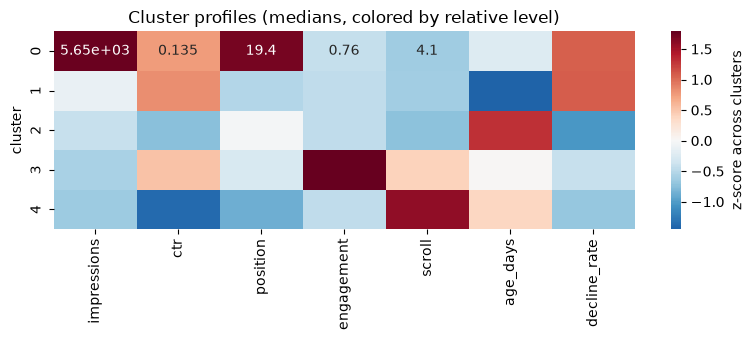

['ml-intern-dataset-and-lane-guide.md', 'index.html', 'data-dictionary.md', 'intern-free-tooling-guide.md', 'results.png', 'ml-core-foundation-framework.md', 'flyrank-seo-research-march-2026.pdf', 'k_selection.png', 'pca_clusters.png', 'profile_heatmap.png', 'results_table.csv', 'archetype_action_playbook.csv']


In [7]:
import shutil, os
z = prof[["impressions", "ctr", "position", "engagement", "scroll", "age_days", "decline_rate"]]
zs = (z - z.mean()) / z.std()
plt.figure(figsize=(8, 3.5))
sns.heatmap(zs, annot=z.values, fmt=".3g", cmap="RdBu_r", center=0, cbar_kws={"label": "z-score across clusters"})
plt.title("Cluster profiles (medians, colored by relative level)"); plt.tight_layout()
plt.savefig("profile_heatmap.png", dpi=150); plt.show()

os.makedirs("docs", exist_ok=True)
for f in ["k_selection.png", "pca_clusters.png", "results.png", "profile_heatmap.png",
          "archetype_action_playbook.csv", "results_table.csv"]:
    if os.path.exists(f): shutil.copy(f, os.path.join("docs", f))
    else: print("MISSING:", f)
print(os.listdir("docs"))

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
